In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
df=pd.read_csv("./DATASETS/Churn_Modelling.csv")
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn


print(df.head())
print(df.shape)



print(df.info())       #to know about null values and data types

print(df.duplicated().sum())    #to know about duplicate rows. 
#if it gives result zero then it means that no duplicate rows in the dataset


print(df['Geography'].value_counts())   

# it will tell which instance occured how many times in geography column

print(df['Gender'].value_counts())

print(df['Exited'].value_counts())

df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)


df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True) 

#to convert categorical columns into numerical columns
X=df.drop(columns='Exited')
y=df['Exited']
print(df.head())
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)


#scaling and standardization of data 

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(X_train)
x_test_scaled=scaler.transform(X_test)


   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [ ]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
#making the model now 
model=Sequential()  #creating the  model

model.add(Dense(3,activation="relu",input_dim=11))  #adding layer in the neural network 
model.add(Dense(3,activation="relu"))  #adding layer in the neural network 
model.add(Dense(1,activation="relu"))  #creatingthe output node

e:\MLJOURNEY\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52 (208.00 B)

 Trainable params: 52 (208.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="binary_crossentropy",optimizer="Adam",metrics=['accuracy'])
#this is final step in this we will compile the model . now our model is ready for fitting

In [ ]:
history=model.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2)
#MODELLING TRAINING

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7633 - loss: 2.7564 - val_accuracy: 0.7694 - val_loss: 2.4892
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7633 - loss: 2.4443 - val_accuracy: 0.7500 - val_loss: 1.9836
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7500 - loss: 2.0127 - val_accuracy: 0.7588 - val_loss: 1.8299
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7630 - loss: 1.7639 - val_accuracy: 0.7625 - val_loss: 1.3551
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7575 - loss: 1.2422 - val_accuracy: 0.7581 - val_loss: 0.9962
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7633 - loss: 1.0062 - val_accuracy: 0.7531 - val_loss: 0.8075
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7484 - loss: 0.7785 - val_accuracy: 0.7550 - val_loss: 0.7301
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7616 - loss: 0.7407 - val_accu

In [ ]:
model.layers[0].get_weights() #it gives the weights in the first layers
model.layers[1].get_weights() #weight in the last layer

[array([[ 1.0405123 ,  0.10735257,  0.731351  ],
        [-0.19276394,  0.6159252 , -0.31006455],
        [ 0.7413122 , -1.3656486 , -0.24194123]], dtype=float32),
 array([-0.19259153,  0.04908757, -0.0787144 ], dtype=float32)]

In [ ]:
y_log=model.predict(x_test_scaled)
#we got the result in between 0 and 1 .
#this is probability of customer leaving or not leaving the bank . 
#we are getting the probabilty beacuse we are using the sigmoid function

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# now converting this probailitic values into categorical values .
# for this we are going to use a very simple threshold(if value is smaller than 0.5 than 0 else 1)
y_pred=np.where(y_log>0.5,1,0) #if y_log greater than 0.5 then else 0
# print(y_pred)
for i in range(1000):
    if y_pred[i]==1:
        print(x_test_scaled[i])
        break


[ 0.16226566  3.35421731  0.68441506  0.45918998 -0.91150957  0.64376017
  0.97725852 -0.93746317  1.71490137 -0.57273139  0.91509065]


In [ ]:
#calculating the accuracy
#FOR THIS WE ARE GOING TO USE SKLEARN
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

#WE CAN IMPROVE THE ACCURACY BY CHANGING THE VALUES OF EPCOHS AND ADDING EXTRA HIDDEN LAYERS
#CHANGING THE ACTUAVTION FUNCTION TO RELU I CAN ALSO INCREASE THE ACCUARCAY ,
#AS RELU CONSIDERED THE BEST ACTIVATION FUNCTION
# BUT DOING THIS IN LARGE  MAY MAKE THE MODEL OVERFIT

0.826

In [ ]:
print(history.history)

{'accuracy': [0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7973437309265137, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7971875071525574, 0.7973437309265137, 0.7973437309265137, 0.7973437309265137, 0.7973437309265137, 0.7971875071525574, 0.7975000143051147, 0.7973437309265137, 0.7971875071525574, 0.7971875071525574, 0.7973437309265137, 0.7971875071525574, 0.7973437309265137, 0.7973437309265137, 0.7973437309265137, 0.7973437309265137, 0.7971875071525574, 0.7973437309265137, 0.7975000143051147, 0.7973

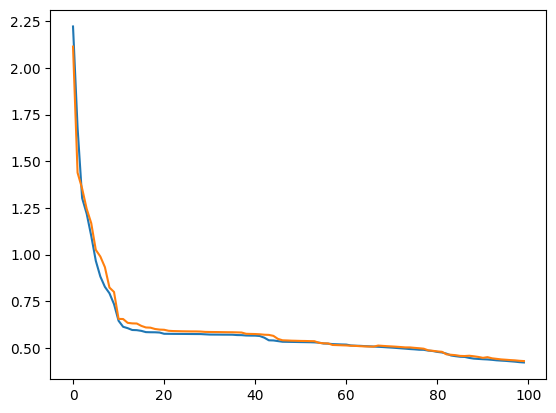

In [ ]:
#PLOTTING THE GRAPHS TO ANALYSE 
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
#WE SAVED THE MODEL TRAINING DETAILS IN THE HISTORY .
#HISTORY IS A DICTIONNARY TO GET FROM HISTROY WE HAVE TO DO "history.histroy[""]"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([[0.03794759]], dtype=float32)

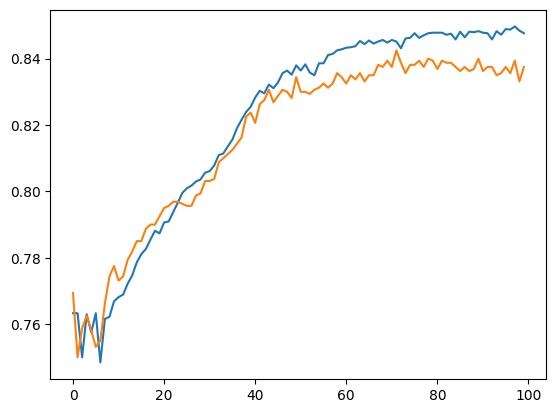

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
model.predict(x_test_scaled)
